In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
df_clean=pd.read_csv("../data/processed/clean_air_quality.csv")

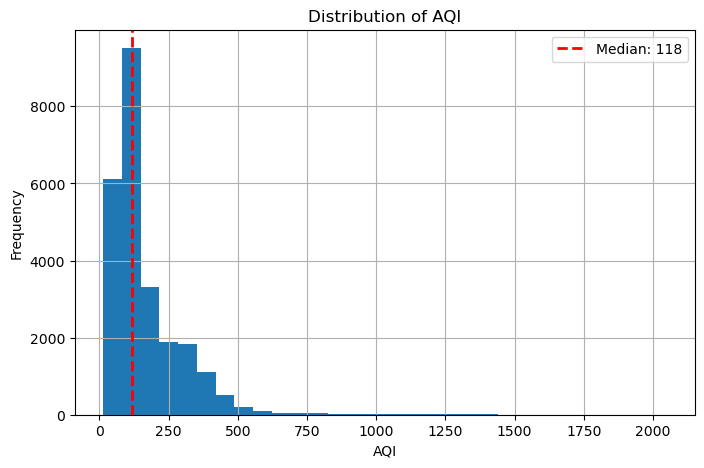

In [3]:
#Which city has the target variable AQI look like
plt.figure(figsize=(8,5))

df_clean["AQI"].hist(bins=30)

plt.axvline(
    df_clean["AQI"].median(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Median: {df_clean['AQI'].median():.0f}"
)

plt.title("Distribution of AQI")
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.legend()

plt.show()

### Observation

- AQI values are positively skewed with a long right tail.
- Most observations fall between approximately 50 and 200 AQI.
- A small number of observations represent extremely poor air quality, resulting in high-value outliers.

### Interpretation

- The dataset is dominated by moderate pollution levels, while severe pollution events are comparatively rare.
- The right-skewed distribution suggests that robust machine learning models and evaluation metrics should be considered.
- Extreme AQI values are likely to represent genuine pollution episodes rather than typical daily conditions.

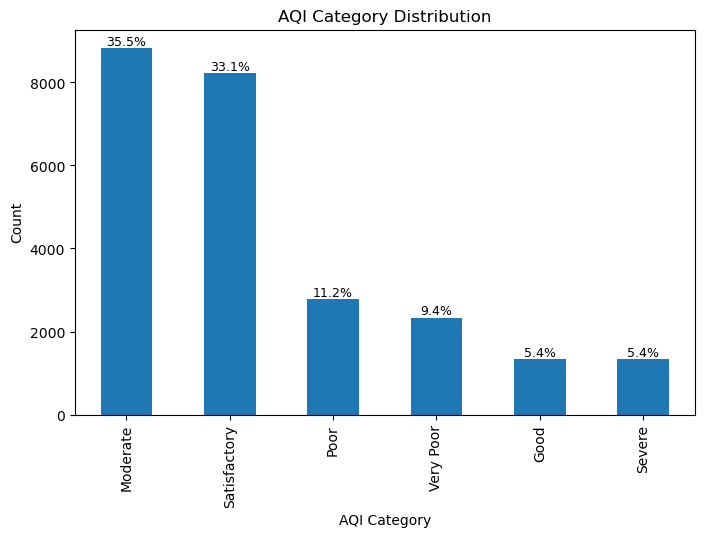

In [11]:
#Which AQI category occurs most often?
aqi_counts = df_clean["AQI_Bucket"].value_counts()

ax = aqi_counts.plot(kind="bar", figsize=(8,5))

plt.title("AQI Category Distribution")
plt.xlabel("AQI Category")
plt.ylabel("Count")

total = len(df_clean)

for p in ax.patches:
    percentage = 100 * p.get_height() / total
    ax.annotate(f"{percentage:.1f}%",
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center',
                va='bottom',
                fontsize=9)

plt.show()

### Observation

- The "Moderate" AQI category has the highest percentage of observations.
- "Satisfactory" is the second most common category.
- "Poor" and "Very Poor" occur less frequently.
- "Good" and "Severe" categories have the fewest observations.
- The AQI categories are imbalanced.

### Interpretation

- Most recorded days experienced moderate air pollution.
- Extreme pollution events (Severe) and very clean air conditions (Good) are comparatively rare.
- The imbalance reflects realistic environmental conditions and should be considered if AQI category classification is performed in future work.

In [5]:
#Which cities have the highest average AQI?
city_avg = (
    df_clean.groupby("City")["AQI"]
            .mean()
            .sort_values(ascending=False)
)

city_avg

City
Ahmedabad             452.122939
Delhi                 259.487744
Patna                 240.782042
Gurugram              225.123882
Lucknow               217.973059
Talcher               172.886819
Jorapokhar            159.251621
Brajrajnagar          150.280505
Kolkata               140.566313
Guwahati              140.111111
Jaipur                133.679159
Bhopal                132.827338
Amritsar              119.920959
Visakhapatnam         117.269855
Chennai               114.502654
Hyderabad             109.207447
Mumbai                105.352258
Kochi                 104.284810
Chandigarh             96.498328
Amaravati              95.299643
Bengaluru              94.318325
Ernakulam              92.359477
Thiruvananthapuram     75.878327
Coimbatore             73.023256
Shillong               53.795122
Aizawl                 34.765766
Name: AQI, dtype: float64

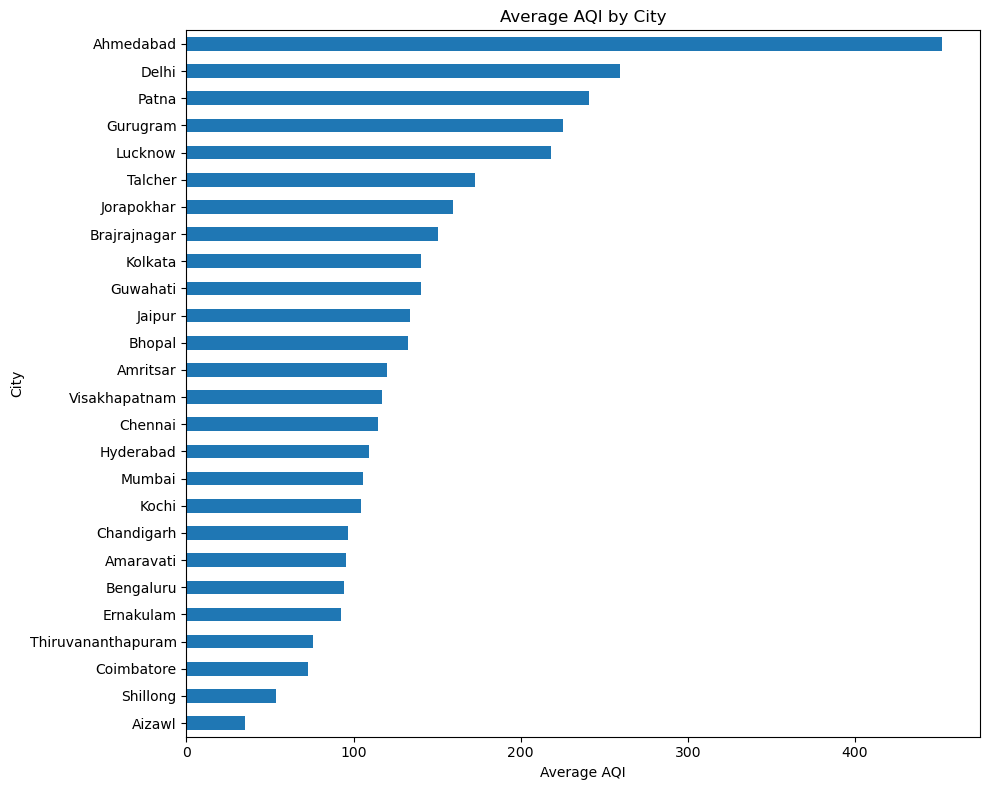

In [12]:
city_avg = (
    df_clean.groupby("City")["AQI"]
            .mean()
            .sort_values()
)

plt.figure(figsize=(10,8))

city_avg.plot(kind="barh")

plt.title("Average AQI by City")
plt.xlabel("Average AQI")
plt.ylabel("City")

plt.tight_layout()
plt.show()

### Observation

- Ahmedabad records the highest average AQI among all cities.
- Delhi, Patna, Gurugram, and Lucknow also experience relatively high average AQI.
- Aizawl, Shillong, Coimbatore, and Thiruvananthapuram have the lowest average AQI.
- Average air quality varies considerably across Indian cities.

### Interpretation

- Air pollution differs significantly between cities.
- Geographic location and urbanization appear to influence AQI.
- The City feature is expected to contribute useful information during machine learning model development.

In [13]:
#Top 10 most Polluted Cities
city_avg.sort_values(ascending=False).head(10)

City
Ahmedabad       452.122939
Delhi           259.487744
Patna           240.782042
Gurugram        225.123882
Lucknow         217.973059
Talcher         172.886819
Jorapokhar      159.251621
Brajrajnagar    150.280505
Kolkata         140.566313
Guwahati        140.111111
Name: AQI, dtype: float64

In [14]:
#Top 10 most clean cities
city_avg.sort_values().head(10)

City
Aizawl                 34.765766
Shillong               53.795122
Coimbatore             73.023256
Thiruvananthapuram     75.878327
Ernakulam              92.359477
Bengaluru              94.318325
Amaravati              95.299643
Chandigarh             96.498328
Kochi                 104.284810
Mumbai                105.352258
Name: AQI, dtype: float64

In [7]:
#Which pollutants are most correlated with AQI?
correlation = df_clean.corr(numeric_only=True)

correlation["AQI"].sort_values(ascending=False)

AQI        1.000000
CO         0.678085
PM2.5      0.655940
NO2        0.535803
SO2        0.485033
NOx        0.471001
PM10       0.457247
NO         0.452230
Toluene    0.279139
O3         0.194298
NH3        0.089704
Benzene    0.048314
Name: AQI, dtype: float64

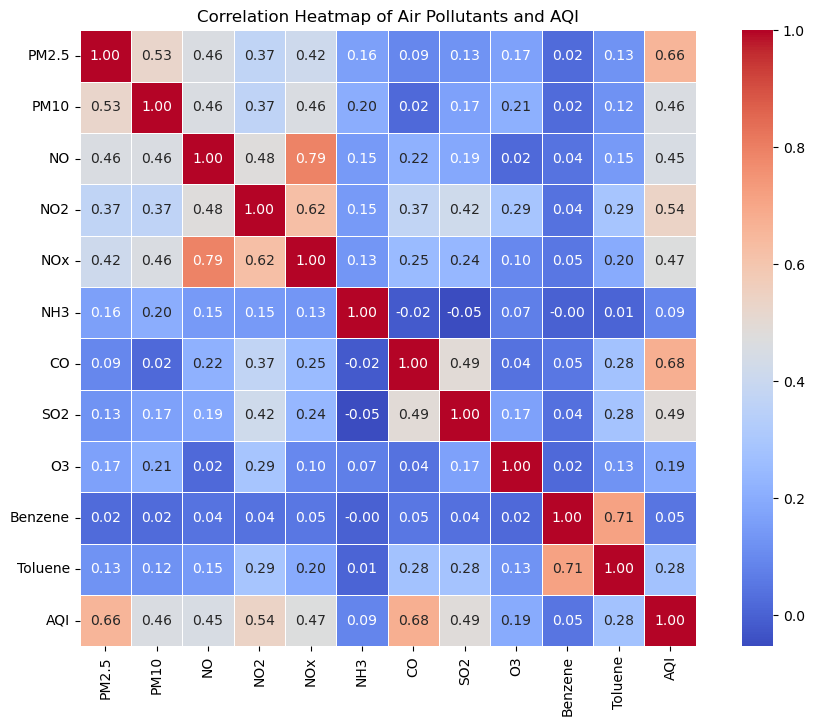

In [15]:


plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Air Pollutants and AQI")
plt.show()

### Observation

- PM2.5 and CO exhibit the strongest positive correlations with AQI.
- NO, NO₂, NOx, and PM10 also show moderate to strong positive relationships with AQI.
- NO and NOx are highly correlated with each other.
- Benzene and Toluene also display a strong positive correlation.

### Interpretation

- PM2.5, CO, NO₂, and PM10 are expected to be important predictors for AQI estimation.
- Strong correlations between certain pollutant pairs indicate possible multicollinearity.
- Since the primary models will be tree-based, these correlated features can initially be retained.

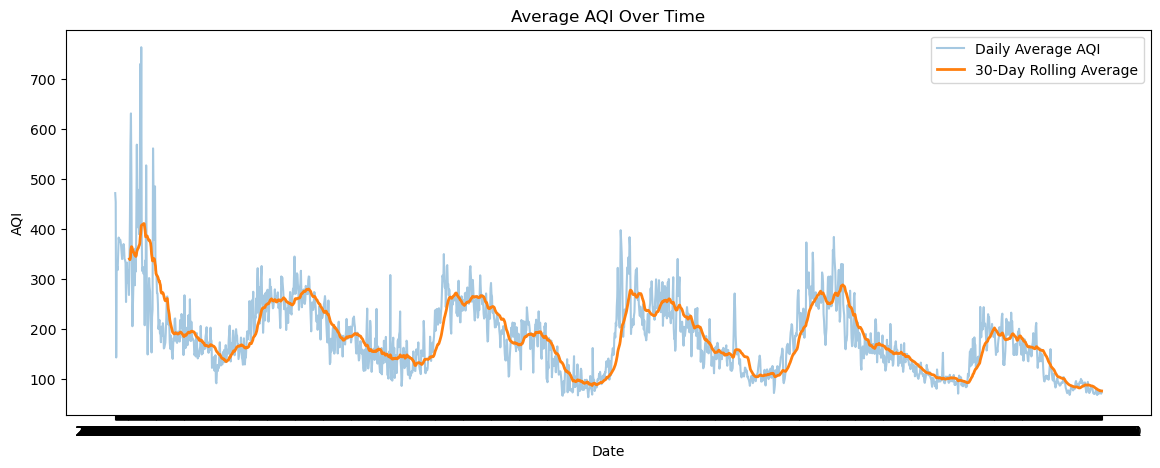

In [16]:
#How has AQI changed over time?
aqi_trend = df_clean.groupby("Date")["AQI"].mean()

rolling_avg = aqi_trend.rolling(window=30).mean()

plt.figure(figsize=(14,5))

plt.plot(aqi_trend, alpha=0.4, label="Daily Average AQI")
plt.plot(rolling_avg, linewidth=2, label="30-Day Rolling Average")

plt.title("Average AQI Over Time")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.legend()

plt.show()

### Observation

- AQI varies significantly over time with frequent fluctuations.
- Several extreme pollution events occur, particularly during the early part of the dataset.
- Similar rising and falling patterns appear across multiple years, suggesting seasonal behavior.
- AQI values appear lower near the end of the dataset, although the data only extends to mid-2020.

### Interpretation

- Air quality is influenced by time-dependent factors.
- Seasonal and yearly patterns may improve predictive performance if incorporated into the machine learning model.
- The observed decline near the end of the dataset should not be interpreted as a long-term improvement because the data is incomplete for 2020.

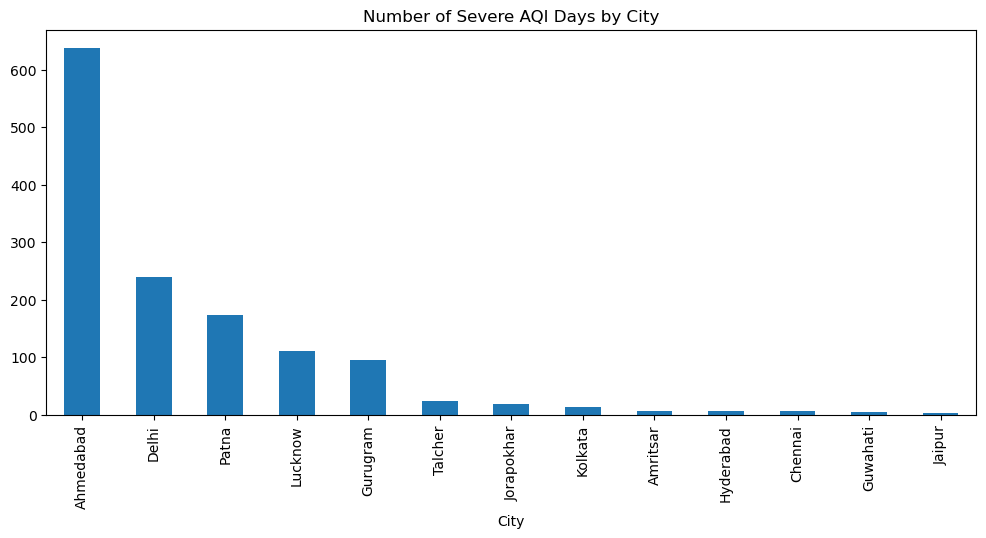

In [10]:
#Which cities experience the most severe pollution?
severe = (
    df_clean[df_clean["AQI_Bucket"] == "Severe"]
    .groupby("City")
    .size()
    .sort_values(ascending=False)
)

severe.plot(
    kind="bar",
    figsize=(12,5)
)

plt.title("Number of Severe AQI Days by City")

plt.show()

### Observation

- Ahmedabad recorded the highest number of Severe AQI days.
- Delhi, Patna, Lucknow, and Gurugram also experienced frequent severe pollution episodes.
- Most remaining cities had comparatively few Severe AQI days.
- Severe pollution events are concentrated in only a few cities.

### Interpretation

- The frequency of severe pollution differs substantially between cities.
- Certain urban regions require greater attention from public health and environmental authorities.
- These findings support the inclusion of personalized, city-specific health recommendations in the AirCare AI application.

# Key EDA Insights

1. AQI values are positively skewed, with most observations between moderate pollution levels and a few extreme pollution events.

2. Moderate and Satisfactory AQI categories account for the majority of observations.

3. Average AQI varies significantly across cities, with Ahmedabad, Delhi, Patna, Gurugram, and Lucknow exhibiting higher pollution levels.

4. PM2.5 and CO demonstrate the strongest positive correlations with AQI, making them important predictors.

5. AQI exhibits recurring temporal fluctuations, suggesting seasonal or time-dependent effects.

6. Severe pollution events are concentrated in a small number of cities, highlighting the need for localized health recommendations.

7. These findings support the development of a machine learning model that predicts AQI and provides personalized health guidance based on the predicted pollution level.